In [2]:
# load this dataset and show its columns: yt_videos_with_local_transcripts.parquet
import pandas as pd
import matplotlib.pyplot as plt
# Load the dataset
file_path = r"yt_videos_with_local_transcripts.parquet"
df = pd.read_parquet(file_path)
# Show the columns of the dataset
print(df.columns)

Index(['thumbnail_default_url', 'videoId', 'publishedAt', 'channelId',
       'channelTitle', 'title', 'description', 'tags', 'categoryId',
       'defaultLanguage', 'defaultAudioLanguage', 'definition', 'caption',
       'licensedContent', 'regionRestriction_blocked', 'license', 'embeddable',
       'madeForKids', 'viewCount', 'likeCount', 'commentCount', 'is_short',
       'is_hd', 'topic_labels_extracted', 'duration_seconds',
       'thumbnail_maxres_url', 'thumbnail_high_url', 'transcript',
       'local_transcript'],
      dtype='str')


In [ ]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display

jobs_path = Path("gcp_jobs/transcript_jobs.jsonl")
rows = []
with jobs_path.open("r", encoding="utf-8") as handle:
    for _, line in zip(range(3), handle):
        record = json.loads(line)
        rows.append(
            {
                "job_id": record.get("job_id"),
                "video_id": record.get("video_id"),
                "title": record.get("title"),
                "chunk_idx": record.get("chunk_idx"),
                "chunk_total": record.get("chunk_total"),
                "estimated_input_tokens": record.get("estimated_input_tokens"),
                "language": record.get("language"),
                "chunk_text_preview": record.get("chunk_text", "")[:300],
            }
        )

display(pd.DataFrame(rows))

,job_id,video_id,title,chunk_idx,chunk_total,estimated_input_tokens,language,chunk_text_preview
0,eNU5FcmEwTc_000,eNU5FcmEwTc,ChatGPT non ha aiutato...,0,1,114,unknown,"Allora, eh questo è molto piccolo, è veramente..."
1,tNbsrpKaMoE_000,tNbsrpKaMoE,TIER LIST - Sanremo Edition con @willwoosh,0,3,1963,unknown,"Ciao amici, oggi faremo una tierlist con un os..."
2,tNbsrpKaMoE_001,tNbsrpKaMoE,TIER LIST - Sanremo Edition con @willwoosh,1,3,1920,unknown,Ci facciamo un cazzo. Ce lo stronchiamo in fro...


In [ ]:
# show the first 5 rows of the dataset in a table view
df.head()

,thumbnail_default_url,videoId,publishedAt,channelId,channelTitle,title,description,tags,categoryId,defaultLanguage,...,likeCount,commentCount,is_short,is_hd,topic_labels_extracted,duration_seconds,thumbnail_maxres_url,thumbnail_high_url,transcript,local_transcript
0,https://i.ytimg.com/vi/eNU5FcmEwTc/default.jpg,eNU5FcmEwTc,2026-02-27 14:16:42+00:00,UC4TFt-3rlYfhc_WtlWWY30Q,Camihawke,ChatGPT non ha aiutato...,NaN,NaN,22,it,...,55.0,0.0,True,1.0,Entertainment,42.0,https://i.ytimg.com/vi/eNU5FcmEwTc/maxresdefau...,https://i.ytimg.com/vi/eNU5FcmEwTc/hqdefault.jpg,"Allora, eh questo è molto piccolo, è veramente...","Allora, eh questo è molto piccolo, è veramente..."
1,https://i.ytimg.com/vi/tNbsrpKaMoE/default.jpg,tNbsrpKaMoE,2026-02-26 13:18:36+00:00,UC4TFt-3rlYfhc_WtlWWY30Q,Camihawke,TIER LIST - Sanremo Edition con @willwoosh,"Il video è ironico, per le informazioni sui ca...",NaN,22,it,...,2563.0,78.0,False,1.0,Entertainment,978.0,https://i.ytimg.com/vi/tNbsrpKaMoE/maxresdefau...,https://i.ytimg.com/vi/tNbsrpKaMoE/hqdefault.jpg,"Ciao amici, oggi faremo una tierlist con un os...","Ciao amici, oggi faremo una tierlist con un os..."
2,https://i.ytimg.com/vi/80cTxK_fA_Q/default.jpg,80cTxK_fA_Q,2026-02-25 12:00:28+00:00,UC4TFt-3rlYfhc_WtlWWY30Q,Camihawke,Dirò una cosa forte!!!,NaN,NaN,22,it,...,422.0,9.0,True,1.0,Lifestyle (sociology),63.0,https://i.ytimg.com/vi/80cTxK_fA_Q/maxresdefau...,https://i.ytimg.com/vi/80cTxK_fA_Q/hqdefault.jpg,dirò una cosa forte. Io se dovessi fare il fig...,dirò una cosa forte. Io se dovessi fare il fig...
3,https://i.ytimg.com/vi/AS6paOwhdR0/default.jpg,AS6paOwhdR0,2026-02-23 12:00:28+00:00,UC4TFt-3rlYfhc_WtlWWY30Q,Camihawke,Voi cose pensate quando qualcuno non vi rispon...,NaN,NaN,22,it,...,141.0,3.0,True,1.0,Lifestyle (sociology),60.0,https://i.ytimg.com/vi/AS6paOwhdR0/maxresdefau...,https://i.ytimg.com/vi/AS6paOwhdR0/hqdefault.jpg,cercare di disintossicarmi dalla validazione d...,cercare di disintossicarmi dalla validazione d...
4,https://i.ytimg.com/vi/wPFcvFEPSSQ/default.jpg,wPFcvFEPSSQ,2026-02-20 12:01:39+00:00,UC4TFt-3rlYfhc_WtlWWY30Q,Camihawke,"Mai avere paura delle risposte, mai più!",NaN,NaN,22,it,...,163.0,3.0,True,1.0,Lifestyle (sociology),61.0,https://i.ytimg.com/vi/wPFcvFEPSSQ/maxresdefau...,https://i.ytimg.com/vi/wPFcvFEPSSQ/hqdefault.jpg,Una cosa su cui ho lavorato molto in terapia q...,Una cosa su cui ho lavorato molto in terapia q...


In [ ]:
# create a time series of the number of videos uploaded per month for this list of channels, and plot it
import pandas as pd
import matplotlib.pyplot as plt

channels = [
    "Mr. Marra",
    "Davide Zambelli",
    "ChiaraMaciTv",
    "Canale di Venti",
    "Smibie Channel",
    "The Lady",
    "Debora Fulli",
    "roccotnl",
    "Camihawke",
    "Il Matricomio",
    "Raissa & Momo",
    "Sara La Rusca",
    "THOMAS BASILICO",
    "Contenuti Zero",
    "Valentina Barbieri",
    "AlicelikeAudrey",
    "Christian Manzoni",
]

# Reload the parquet so this cell does not depend on stale notebook state
plot_df = pd.read_parquet(file_path)

# Detect the needed columns
author_col = next((col for col in ["channelTitle", "channel_title", "channelName", "uploader"] if col in plot_df.columns), None)
date_col = next((col for col in ["publishedAt", "upload_date", "published_at"] if col in plot_df.columns), None)
if author_col is None:
    raise KeyError(f"No expected channel column found. Available columns: {list(plot_df.columns)}")
if date_col is None:
    raise KeyError(f"No expected date column found. Available columns: {list(plot_df.columns)}")

# Figure out the dtype and normalize it to timezone-naive datetime
print(f"{date_col} dtype before conversion: {plot_df[date_col].dtype}")
plot_df[date_col] = pd.to_datetime(plot_df[date_col], errors='coerce', utc=True)
plot_df[date_col] = plot_df[date_col].dt.tz_convert(None)
print(f"{date_col} dtype after conversion: {plot_df[date_col].dtype}")

# Keep only the requested channels and build monthly counts
plot_df = plot_df[plot_df[author_col].isin(channels)].copy()
plot_df = plot_df.dropna(subset=[date_col])
plot_df["month"] = plot_df[date_col].dt.to_period("M").dt.to_timestamp("M")
monthly_counts = (
    plot_df.groupby([author_col, "month"]).size().reset_index(name="videos")
)

# Use a small number of multi-line plots instead of one panel per channel
plot_groups = [
    ["Mr. Marra", "Davide Zambelli", "ChiaraMaciTv", "Canale di Venti", "Smibie Channel"],
    ["The Lady", "Debora Fulli", "roccotnl", "Camihawke"],
    ["Il Matricomio", "Raissa & Momo", "Sara La Rusca", "THOMAS BASILICO"],
    ["Contenuti Zero", "Valentina Barbieri", "AlicelikeAudrey", "Christian Manzoni"],
]

for group_index, group in enumerate(plot_groups, start=1):
    fig, ax = plt.subplots(figsize=(14, 6))
    for channel in group:
        channel_series = monthly_counts[monthly_counts[author_col] == channel].sort_values("month")
        ax.plot(channel_series["month"], channel_series["videos"], marker="o", linewidth=1.8, label=channel)

    ax.set_title(f"Monthly video uploads per channel (group {group_index} of {len(plot_groups)})")
    ax.set_xlabel("Month")
    ax.set_ylabel("Videos")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=9)
    plt.tight_layout()
    plt.show()

publishedAt dtype before conversion: str
publishedAt dtype after conversion: datetime64[us]


Error: AttributeError: module 'matplotlib' has no attribute 'backends'
[31m---------------------------------------------------------------------------[39m
[31mAttributeError[39m                            Traceback (most recent call last)
[36mCell[39m[36m [39m[32mIn[11][39m[32m, line 59[39m
[32m     55[39m     [[33m"Contenuti Zero"[39m, [33m"Valentina Barbieri"[39m, [33m"AlicelikeAudrey"[39m, [33m"Christian Manzoni"[39m],
[32m     56[39m ]
[32m     57[39m 
[32m     58[39m [38;5;28;01mfor[39;00m group_index, group [38;5;28;01min[39;00m enumerate(plot_groups, start=[32m1[39m):
[32m---> [39m[32m59[39m     fig, ax = plt.subplots(figsize=([32m14[39m, [32m6[39m))
[32m     60[39m     [38;5;28;01mfor[39;00m channel [38;5;28;01min[39;00m group:
[32m     61[39m         channel_series = monthly_counts[monthly_counts[author_col] == channel].sort_values([33m"month"[39m)
[32m     62[39m         ax.plot(channel_series[[33m"month"[39m], channel_s

Error in callback <function _enable_matplotlib_integration.<locals>.configure_once at 0x00000271DB0C93A0> (for post_run_cell), with arguments args (<ExecutionResult object at 2727f68fb50, execution_count=11 error_before_exec=None error_in_exec=module 'matplotlib' has no attribute 'backends' info=<ExecutionInfo object at 271f19efcd0, raw_cell="# create a time series of the number of videos upl.." transformed_cell="# create a time series of the number of videos upl.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/c%3A/Users/Mohammad%20Reza/OneDrive%20-%20Politecnico%20di%20Milano/Showreel/reza/Data_Cleaned/Untitled-1.ipynb#X14sZmlsZQ%3D%3D> result=None>,),kwargs {}:


Error: AttributeError: module 'matplotlib' has no attribute 'backends'
[31m---------------------------------------------------------------------------[39m
[31mAttributeError[39m                            Traceback (most recent call last)
[36mFile [39m[32md:\miniconda\envs\showreel-kernel\Lib\site-packages\matplotlib_inline\backend_inline.py:229[39m, in [36m_enable_matplotlib_integration.<locals>.configure_once[39m[34m(*args)[39m
[32m    228[39m [38;5;28;01mdef[39;00m[38;5;250m [39m[34mconfigure_once[39m(*args):
[32m--> [39m[32m229[39m     [30;43mactivate_matplotlib[39;49m[30;43m([39;49m[30;43mbackend[39;49m[30;43m)[39;49m
[32m    230[39m     configure_inline_support(ip, backend)
[32m    231[39m     ip.events.unregister([33m"[39m[33mpost_run_cell[39m[33m"[39m, configure_once)

[36mFile [39m[32md:\miniconda\envs\showreel-kernel\Lib\site-packages\matplotlib\pyplot.py:519[39m, in [36mswitch_backend[39m[34m(newbackend)[39m
[32m    514[39m

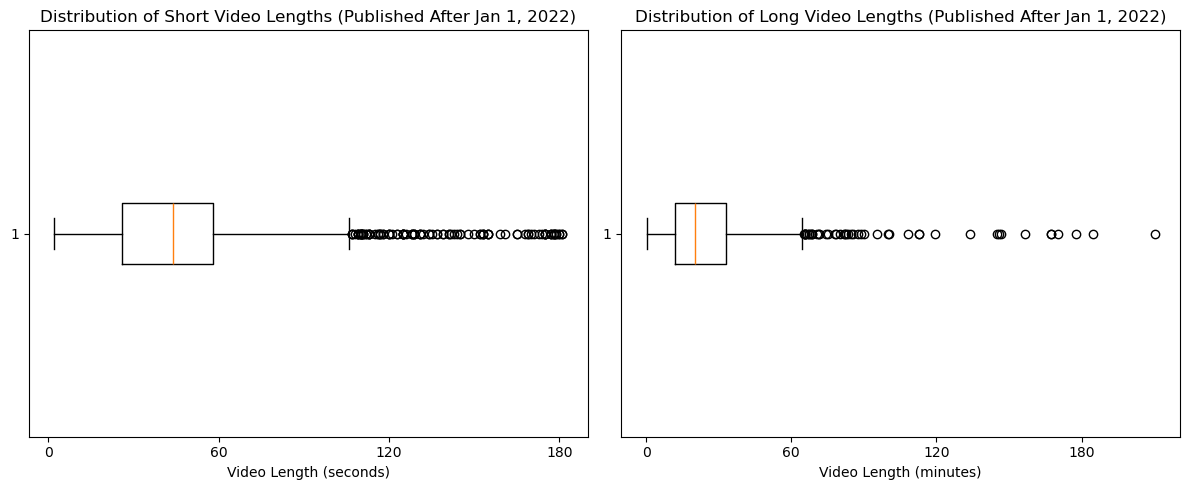

In [4]:
# do the same but filter videos for the 'is_short' column and plot two graphs one for each value of 'is_short'
# Reload the parquet so this cell does not depend on stale notebook state
boxplot_df = pd.read_parquet(file_path)
boxplot_df = boxplot_df[boxplot_df['publishedAt'] > '2022-01-01']
short_videos = boxplot_df[boxplot_df['is_short'] == True]
long_videos = boxplot_df[boxplot_df['is_short'] == False]
# Plot for short videos
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.boxplot(short_videos['duration_seconds'], vert=False)
plt.xlabel('Video Length (seconds)')
plt.xticks(ticks=range(0, int(short_videos['duration_seconds'].max()) + 1, 60))
plt.title('Distribution of Short Video Lengths (Published After Jan 1, 2022)')
# Plot for long videos; the unit of measurement should be minutes, and markers on the horizontal axis should be on 60, 120, 180, etc. (multiples of 60)
plt.subplot(1, 2, 2)
plt.boxplot(long_videos['duration_seconds']/60, vert=False)
plt.xlabel('Video Length (minutes)')
plt.title('Distribution of Long Video Lengths (Published After Jan 1, 2022)')
plt.xticks(ticks=range(0, int(long_videos['duration_seconds'].max()/60) + 1, 60))
plt.tight_layout()
plt.show()
# draw a normal distribution curve for them as well.


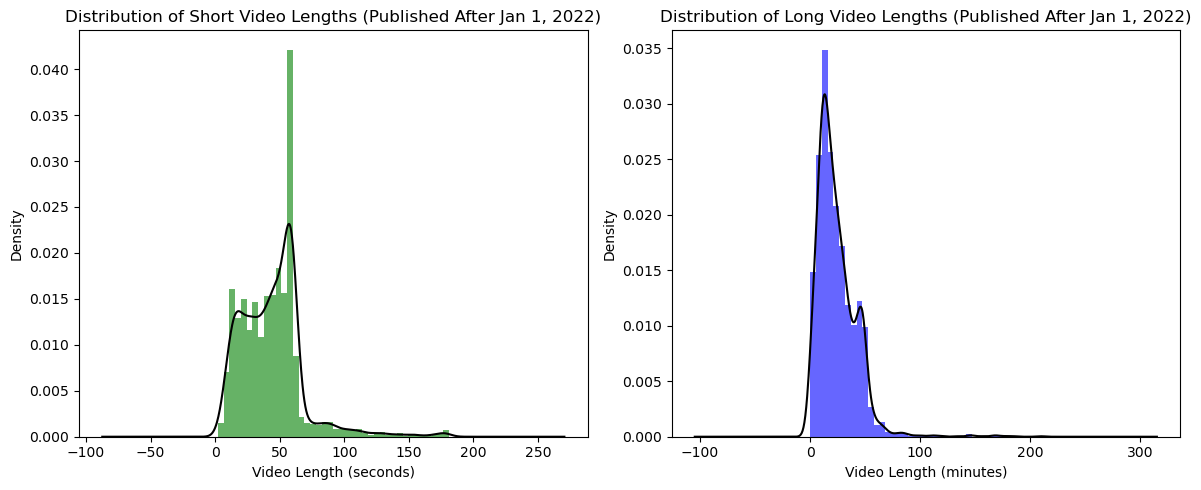

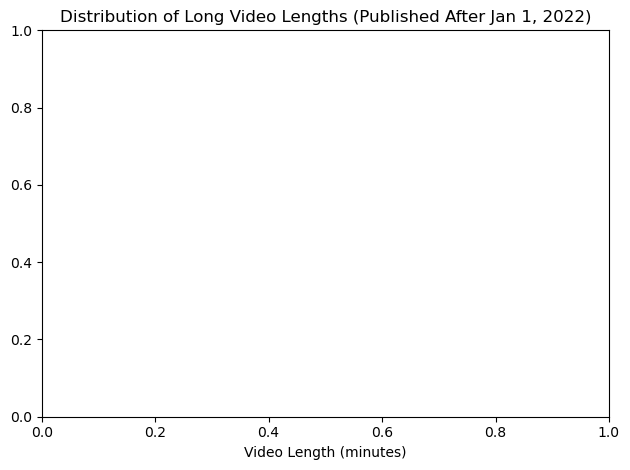

In [6]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
short_videos['duration_seconds'].plot(kind='hist', bins=40, density=True, alpha=0.6, color='g')
short_videos['duration_seconds'].plot(kind='kde', color='black')
plt.xlabel('Video Length (seconds)')
plt.title('Distribution of Short Video Lengths (Published After Jan 1, 2022)')
plt.subplot(1, 2, 2)
(long_videos['duration_seconds']/60).plot(kind='hist', bins=40, density=True, alpha=0.6, color='b')
(long_videos['duration_seconds']/60).plot(kind='kde', color='black')
plt.xlabel('Video Length (minutes)')
plt.title('Distribution of Long Video Lengths (Published After Jan 1, 2022)')
plt.tight_layout()
plt.show()
plt.xlabel('Video Length (minutes)')
plt.title('Distribution of Long Video Lengths (Published After Jan 1, 2022)')
plt.tight_layout()
plt.show()

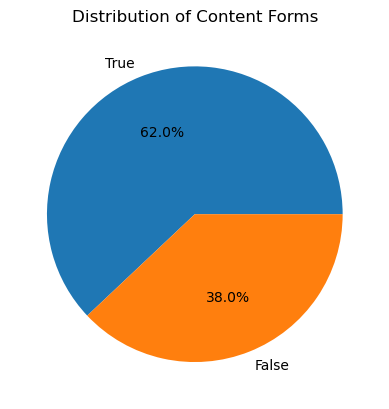

In [ ]:
# show the distribution of content form for the videos in this dataset, using a pie chart. The content form is in the 'is_short' column.
import pandas as pd
import matplotlib.pyplot as plt

content_distribution = boxplot_df['is_short'].value_counts()
plt.pie(content_distribution.values, labels=content_distribution.index, autopct='%1.1f%%')
plt.title('Distribution of Content Forms')
plt.show()

In [ ]:
# Inspect raw transcript samples to understand cleaning needs
import pandas as pd

df_t = pd.read_parquet("yt_videos_with_local_transcripts.parquet")

last_col = df_t.columns[-1]
print(f"Last column (transcript col): '{last_col}'")
print(f"Total rows: {len(df_t)}")
print(f"Non-null transcripts: {df_t[last_col].notna().sum()}")
print()

messy = df_t[df_t[last_col].notna() & (df_t[last_col].str.len() > 50)].head(8)
for i, (_, row) in enumerate(messy.iterrows()):
    t = str(row[last_col])
    vid = row.get("videoId", row.get("video_id", "?"))
    print(f"{'='*70}")
    print(f"Sample {i+1}  |  video_id={vid}  |  len={len(t)}")
    print(f"{'='*70}")
    print(t[:1000])
    print()


Last column (transcript col): 'local_transcript'
Total rows: 12829
Non-null transcripts: 11801

Sample 1  |  video_id=eNU5FcmEwTc  |  len=454
Allora, eh questo è molto piccolo, è veramente piccolo. >> È di Morg, >> è di Brock, volevi dire >> è di Brock, >> ma poi chi è di Morg? >> Mi piace di Brock. >> Ti piace? Sì, >> p Sì, è la mia vibe. Cosa fai di Brock oltre la musica? Questa è qui la vera domanda da fare. >> Parliamo di Brock, allora chiediamo subito una cosa. Non fa musica. giornalista investigativa >> prima di Venom. >> Ah, >> cosa fai di Broccolt musica? La risposta onesta è poco.

Sample 2  |  video_id=tNbsrpKaMoE  |  len=18644
Ciao amici, oggi faremo una tierlist con un ospite speciale, non so se lo conoscete, lui è un piccolo creator. Io diciamo fatto questo format anche per sostenere i piccoli creator. Lui si chiama Guglielmo Shilla e su YouTube vuoi dire tu i tuoi canali, magari >> e magari mi puoi me li puoi lasciare nell'infobox. nell'infobox. nell'infobox. >> Certo. Sì

In [ ]:
# Diagnose which VTT artifacts are still present after the existing cleaning
import pandas as pd, re

df_t = pd.read_parquet("yt_videos_with_local_transcripts.parquet")
last_col = df_t.columns[-1]
texts = df_t[last_col].dropna().astype(str)

patterns = {
    "HTML entity (e.g. &amp; &#39;)":   r"&[a-zA-Z#][a-zA-Z0-9]+;",
    "Inline VTT timestamp (<00:00:…>)": r"<\d{2}:\d{2}:\d{2}[\.,]\d+>",
    "Cue settings (align: / position:)":r"(?:align|position|line|size):\S+",
    "NOTE block":                        r"\bNOTE\b",
    "Kind:/Language: header":            r"(?:Kind|Language):\s*\S+",
    "STYLE block":                       r"\bSTYLE\b",
    "Repeated consecutive sentence":     None,   # handled separately
    "Leftover arrow  -->":               r"-->",
    "Leftover digit-only line":          r"(?m)^\d+$",
}

print(f"Total non-null transcripts: {len(texts)}\n")
for label, pat in patterns.items():
    if pat is None:
        continue
    count = texts.str.contains(pat, regex=True, na=False).sum()
    if count:
        # show one example
        example_row = texts[texts.str.contains(pat, regex=True, na=False)].iloc[0]
        hit = re.search(pat, example_row)
        snippet = example_row[max(0, hit.start()-30):hit.end()+30] if hit else ""
        print(f"  [{count:>4} rows]  {label}")
        print(f"             e.g. → {repr(snippet)}")
    else:
        print(f"  [   0 rows]  {label}  ✓ clean")

# Check for duplicate consecutive sentences (most common VTT artefact)
dup_count = 0
for t in texts:
    sentences = [s.strip() for s in t.split(".") if s.strip()]
    for a, b in zip(sentences, sentences[1:]):
        if a and a == b:
            dup_count += 1
            break
print(f"\n  [{dup_count:>4} rows]  Repeated consecutive sentence (VTT overlap artefact)")


Total non-null transcripts: 11801

  [   0 rows]  HTML entity (e.g. &amp; &#39;)  ✓ clean
  [   0 rows]  Inline VTT timestamp (<00:00:…>)  ✓ clean
  [   0 rows]  Cue settings (align: / position:)  ✓ clean
  [   0 rows]  NOTE block  ✓ clean
  [   0 rows]  Kind:/Language: header  ✓ clean
  [   0 rows]  STYLE block  ✓ clean
  [   0 rows]  Leftover arrow  -->  ✓ clean
  [   0 rows]  Leftover digit-only line  ✓ clean

  [1196 rows]  Repeated consecutive sentence (VTT overlap artefact)


In [ ]:
# ── Re-clean local_transcript column in parquet ───────────────────────────────
import html, re, pandas as pd
from pathlib import Path

_VTT_HEADER_RE  = re.compile(r"\b(?:Kind|Language)\s*:\s*\S+", re.IGNORECASE)
_CUE_SETTING_RE = re.compile(r"\b(?:align|position|line|size)\s*:\s*[0-9a-zA-Z%.-]+", re.IGNORECASE)
_EMPTY_ANGLE_RE = re.compile(r"<>")
_WHITESPACE_RE  = re.compile(r"\s{2,}")

def _dedup_vtt(text: str, min_len: int = 4) -> str:
    words = text.split()
    if len(words) < min_len * 2:
        return text
    out = words[:min_len]
    i = min_len
    while i < len(words):
        max_w, skipped = min(30, len(words) - i), False
        for w in range(max_w, min_len - 1, -1):
            if len(out) >= w and words[i:i+w] == out[-w:]:
                i += w; skipped = True; break
        if not skipped:
            out.append(words[i]); i += 1
    return " ".join(out)

def deep_clean(text):
    if not isinstance(text, str) or not text.strip():
        return text
    text = html.unescape(text)
    text = _VTT_HEADER_RE.sub("", text)
    text = _CUE_SETTING_RE.sub("", text)
    text = _EMPTY_ANGLE_RE.sub("", text)
    text = _WHITESPACE_RE.sub(" ", text).strip()
    return _dedup_vtt(text)

parquet_path = Path("yt_videos_with_local_transcripts.parquet")
df = pd.read_parquet(parquet_path)
last_col = df.columns[-1]

before_len = df[last_col].dropna().str.len().mean()
df[last_col] = df[last_col].apply(deep_clean)
after_len  = df[last_col].dropna().str.len().mean()

df.to_parquet(parquet_path, index=False)
print(f"Saved {len(df)} rows  →  {parquet_path}")
print(f"Avg transcript length: {before_len:.0f} chars  →  {after_len:.0f} chars (Δ {after_len - before_len:+.0f})")


Saved 12829 rows  →  yt_videos_with_local_transcripts.parquet
Avg transcript length: 33604 chars  →  9369 chars (Δ -24234)


In [ ]:
# ── Regenerate all JSONL files from the cleaned parquet ───────────────────────
# Run AFTER the re-clean cell above.
import subprocess, sys

base = ["python", "pipeline_tools/prepare_transcript_jobs.py"]
runs = [
    # production  (1800-token chunks)
    dict(args=base + [
        "--input",    "yt_videos_with_local_transcripts.parquet",
        "--output",   "gcp_jobs/transcript_jobs.jsonl",
        "--manifest", "gcp_jobs/transcript_jobs_manifest.json",
        "--rejects",  "gcp_jobs/transcript_rejects.jsonl",
        "--max-tokens", "1800", "--overlap-tokens", "150",
        "--tokenizer-name", "cl100k_base", "--prompt-version", "v1",
    ], label="production"),
    # test v2  (400-token chunks, cl100k_base)
    dict(args=base + [
        "--input",    "yt_videos_with_local_transcripts.parquet",
        "--output",   "gcp_jobs/test_transcript_jobs_v2.jsonl",
        "--manifest", "gcp_jobs/test_transcript_jobs_manifest_v2.json",
        "--rejects",  "gcp_jobs/test_transcript_rejects_v2.jsonl",
        "--max-tokens", "400", "--overlap-tokens", "50",
        "--tokenizer-name", "cl100k_base", "--prompt-version", "v1",
        "--dedupe",
    ], label="test-v2"),
    # test v1  (400-token chunks, fallback tokenizer — no tiktoken model name)
    dict(args=base + [
        "--input",    "yt_videos_with_local_transcripts.parquet",
        "--output",   "gcp_jobs/test_transcript_jobs.jsonl",
        "--manifest", "gcp_jobs/test_transcript_jobs_manifest.json",
        "--rejects",  "gcp_jobs/test_transcript_rejects.jsonl",
        "--max-tokens", "400", "--overlap-tokens", "50",
        "--prompt-version", "v1",
        "--dedupe",
    ], label="test-v1"),
]

for run in runs:
    result = subprocess.run(run["args"], capture_output=True, text=True)
    status = "OK" if result.returncode == 0 else "FAILED"
    print(f"[{status}] {run['label']}")
    if result.stdout.strip():
        print("  ", result.stdout.strip())
    if result.stderr.strip():
        print("  STDERR:", result.stderr.strip()[:300])


[OK] production
   Wrote 22469 job records to gcp_jobs\transcript_jobs.jsonl
Wrote 1033 rejected rows to gcp_jobs\transcript_rejects.jsonl
Wrote manifest to gcp_jobs\transcript_jobs_manifest.json
[OK] test-v2
   Wrote 76469 job records to gcp_jobs\test_transcript_jobs_v2.jsonl
Wrote 1107 rejected rows to gcp_jobs\test_transcript_rejects_v2.jsonl
Wrote manifest to gcp_jobs\test_transcript_jobs_manifest_v2.json
[OK] test-v1
   Wrote 76469 job records to gcp_jobs\test_transcript_jobs.jsonl
Wrote 1107 rejected rows to gcp_jobs\test_transcript_rejects.jsonl
Wrote manifest to gcp_jobs\test_transcript_jobs_manifest.json


In [ ]:
# Job structure: how many chunks per video?
import json, pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

records = [json.loads(l) for l in Path("gcp_jobs/transcript_jobs.jsonl").read_text(encoding="utf-8").splitlines()]
df_jobs = pd.DataFrame(records)

chunks_per_video = df_jobs.groupby("video_id")["chunk_idx"].max() + 1  # max idx + 1 = total chunks

print(f"Total jobs  : {len(df_jobs):,}")
print(f"Unique videos: {df_jobs['video_id'].nunique():,}")
print(f"\nChunks-per-video distribution:")
print(chunks_per_video.value_counts().sort_index().rename("video count").to_string())

fig, ax = plt.subplots(figsize=(10, 4))
chunks_per_video.value_counts().sort_index().plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_xlabel("Number of chunks (jobs) for this video")
ax.set_ylabel("Number of videos")
ax.set_title("Chunks per video — production JSONL (1800-token chunks, 150-token overlap)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nFor the embedding phase: embed each chunk, then mean-pool back to 1 vector per video.")


In [ ]:
import pandas as pd

# Draw another sample set of transcripts to check if they are fixed

messy = df[df[last_col].notna() & (df[last_col].str.len() > 50)].head(8)
for i, (_, row) in enumerate(messy.iterrows()):
    t = str(row[last_col])
    vid = row.get("videoId", row.get("video_id", "?"))
    print(f"{'='*70}")
    print(f"Sample {i+1}  |  video_id={vid}  |  len={len(t)}")
    print(f"{'='*70}")
    print(t[:1000])
    print()

Sample 1  |  video_id=eNU5FcmEwTc  |  len=454
Allora, eh questo è molto piccolo, è veramente piccolo. >> È di Morg, >> è di Brock, volevi dire >> è di Brock, >> ma poi chi è di Morg? >> Mi piace di Brock. >> Ti piace? Sì, >> p Sì, è la mia vibe. Cosa fai di Brock oltre la musica? Questa è qui la vera domanda da fare. >> Parliamo di Brock, allora chiediamo subito una cosa. Non fa musica. giornalista investigativa >> prima di Venom. >> Ah, >> cosa fai di Broccolt musica? La risposta onesta è poco.

Sample 2  |  video_id=tNbsrpKaMoE  |  len=18644
Ciao amici, oggi faremo una tierlist con un ospite speciale, non so se lo conoscete, lui è un piccolo creator. Io diciamo fatto questo format anche per sostenere i piccoli creator. Lui si chiama Guglielmo Shilla e su YouTube vuoi dire tu i tuoi canali, magari >> e magari mi puoi me li puoi lasciare nell'infobox. nell'infobox. nell'infobox. >> Certo. Sì, sì, li trovate qua sotto. Allora, oggi tier listiamo eh visto che è un po' la settimana di San

In [ ]:
# Filter videos from 2022 onwards
df_2022_onwards = df[df['publishedAt'] > '2022-01-01'].copy()

# Calculate word count for each transcript
df_2022_onwards['word_count'] = df_2022_onwards[last_col].fillna('').str.split().str.len()

# Split by form (short vs long)
shorts_2022 = df_2022_onwards[df_2022_onwards['is_short'] == True]
longs_2022 = df_2022_onwards[df_2022_onwards['is_short'] == False]

print(f"Total videos since 2022: {len(df_2022_onwards)}")
print(f"  Short videos: {len(shorts_2022)}")
print(f"  Long videos: {len(longs_2022)}\n")

# Plot word count distribution for each category
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
shorts_2022['word_count'].plot(kind='hist', bins=40, density=True, alpha=0.6, color='g', edgecolor='black')
shorts_2022['word_count'].plot(kind='kde', color='black', linewidth=2)
plt.xlabel('Word Count')
plt.ylabel('Density')
plt.title('Word Count Distribution - Short Videos (2022+)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
longs_2022['word_count'].plot(kind='hist', bins=40, density=True, alpha=0.6, color='b', edgecolor='black')
longs_2022['word_count'].plot(kind='kde', color='black', linewidth=2)
plt.xlabel('Word Count')
plt.ylabel('Density')
plt.title('Word Count Distribution - Long Videos (2022+)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nShort Videos - Word Count Statistics:")
print(shorts_2022['word_count'].describe())
print(f"\nLong Videos - Word Count Statistics:")
print(longs_2022['word_count'].describe())

## Comments dataset — structure & basic stats

Understand the four `yt_comments_*_cleaned.parquet` files before building the NER pipeline.

In [2]:
# ── Comments dataset: schema, size, and sample text ──────────────────────────
import pandas as pd
from pathlib import Path

comment_files = sorted(Path(".").glob("yt_comments_*_cleaned.parquet"))
frames = [pd.read_parquet(p) for p in comment_files]
df_comments = pd.concat(frames, ignore_index=True)

print(f"Files loaded : {[p.name for p in comment_files]}")
print(f"Total rows   : {len(df_comments):,}")
print(f"Columns      : {df_comments.columns.tolist()}")
print()
print("── isReply distribution ──")
print(df_comments["isReply"].value_counts())
print()
print("── likeCount distribution ──")
print(df_comments["likeCount"].describe())
print()
print("── null counts per column ──")
print(df_comments.isnull().sum())
print()
print("── text samples (top-level comments) ──")
sample = df_comments[df_comments["isReply"] == False]["textOriginal"].dropna().sample(5, random_state=42)
for i, t in enumerate(sample, 1):
    print(f"\n[{i}] {str(t)[:300]}")

Files loaded : ['yt_comments_1_cleaned.parquet', 'yt_comments_2_cleaned.parquet', 'yt_comments_3_cleaned.parquet', 'yt_comments_4_cleaned.parquet']
Total rows   : 3,142,109
Columns      : ['threadId', 'commentId', 'videoId', 'canReply', 'channelId', 'authorChannelId', 'textOriginal', 'likeCount', 'viewerRating', 'canRate', 'publishedAt', 'updatedAt', 'totalReplyCount', 'isReply']

── isReply distribution ──
isReply
False    2573820
True      568289
Name: count, dtype: int64

── likeCount distribution ──
count    3.142109e+06
mean     3.364322e+00
std      4.794056e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.000000e+00
max      2.032400e+04
Name: likeCount, dtype: float64

── null counts per column ──
threadId                0
commentId               0
videoId                 0
canReply                0
channelId               0
authorChannelId         0
textOriginal         1342
likeCount               0
viewerRating            0
canRate            

In [ ]:
# ── Comments per video — distribution ────────────────────────────────────────
import matplotlib.pyplot as plt

comments_per_video = df_comments.groupby("videoId").size()

print(f"Videos with at least one comment: {len(comments_per_video):,}")
print(f"Videos in transcript parquet    : {df['videoId'].nunique():,}")
overlap = set(comments_per_video.index) & set(df["videoId"])
print(f"Overlap (both transcript + comment): {len(overlap):,}")
print()
print(comments_per_video.describe())

fig, ax = plt.subplots(figsize=(10, 4))
comments_per_video.clip(upper=500).plot(kind="hist", bins=60, ax=ax,
                                         color="steelblue", edgecolor="white")
ax.set_xlabel("Comments per video (capped at 500 for readability)")
ax.set_ylabel("Number of videos")
ax.set_title("Distribution of comment count per video")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()